In [1]:
from sklearn.preprocessing import PowerTransformer

In [2]:
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
from get_path import get_path as gp

In [22]:
df = pd.read_csv(gp()).iloc[:, 0:5].dropna()

In [23]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
8,13.00,21.82,87.50,519.8,0.12730
13,15.85,23.95,103.70,782.7,0.08401
14,13.73,22.61,93.60,578.3,0.11310
...,...,...,...,...,...
549,10.82,24.21,68.89,361.6,0.08192
550,10.86,21.48,68.51,360.5,0.07431
560,14.05,27.15,91.38,600.4,0.09929
564,21.56,22.39,142.00,1479.0,0.11100


Text(0.5, 1.0, 'mean radius per record')

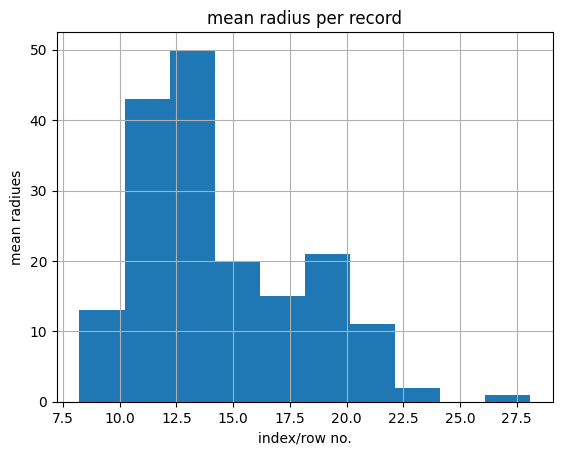

In [27]:
df.iloc[:, 0].hist()
plt.xlabel("index/row no.")
plt.ylabel("mean radiues")
plt.title("mean radius per record")

### **We see that the data is *right-skewed*, and does *not* follow *normal distribution***
### **To normalize distribution, we apply power transformer.**

### **This is the Yeo-Johnson pwower transformer(default method)**
### with standardization

In [28]:
power = PowerTransformer()

In [29]:
t = power.fit_transform(df)

In [30]:
t

array([[ 1.39469851e+00,  5.10996621e-01,  1.38089374e+00,
         1.39112945e+00,  8.89375284e-01],
       [-8.39115598e-01,  3.27773867e-01, -5.97833808e-01,
        -9.22510330e-01,  2.68293761e+00],
       [-2.44258158e-01,  6.27334554e-01, -8.28003524e-02,
        -2.44759573e-01,  1.91933168e+00],
       [ 5.86888765e-01,  1.03861937e+00,  5.86306973e-01,
         6.01026683e-01, -9.25030541e-01],
       [-5.87313379e-03,  7.84030357e-01,  1.90504584e-01,
        -1.50073232e-02,  1.10624790e+00],
       [ 1.41588009e+00,  6.93415463e-01,  1.38089374e+00,
         1.47070113e+00,  1.40968830e-01],
       [-2.17127955e-01, -7.98353622e-01, -1.72671776e-01,
        -2.43918525e-01,  7.55917137e-01],
       [-1.75596827e+00, -1.78494513e+00, -1.79454025e+00,
        -1.77785318e+00,  4.21015234e-01],
       [ 8.90051033e-01, -6.14164798e-01,  9.93307863e-01,
         8.94434241e-01,  1.43351674e+00],
       [ 2.47964330e-01,  5.68499268e-01,  3.47394882e-01,
         2.12550619e-01

(array([ 4.,  7., 13., 34., 39., 22., 20., 27.,  9.,  1.]),
 array([-2.54500998, -2.03906969, -1.53312939, -1.0271891 , -0.5212488 ,
        -0.01530851,  0.49063179,  0.99657209,  1.50251238,  2.00845268,
         2.51439297]),
 <BarContainer object of 10 artists>)

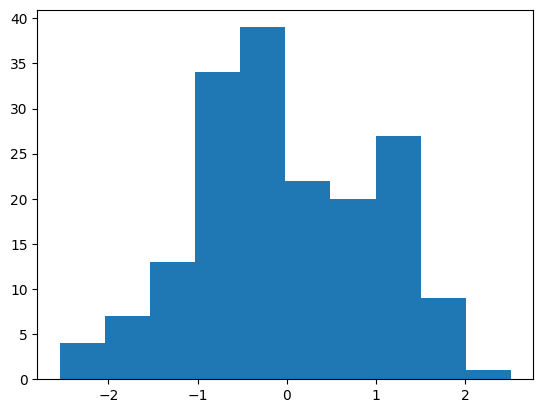

In [34]:
plt.hist(t[:, 0])

### **Without standardization**

In [35]:
power = PowerTransformer(standardize=False)
#standardization essentially just centers the gaussian distribution around 0; even without standardization the gaussian distribution remains
#,just around some other non-zero value.

In [36]:
t = power.fit_transform(df)

In [37]:
t

array([[1.29436516, 3.28719548, 1.59610278, 3.07615188, 0.0674089 ],
       [1.21479227, 3.24249651, 1.56272517, 2.89368613, 0.07743564],
       [1.23598227, 3.31557725, 1.57141287, 2.9471371 , 0.07316678],
       [1.26558938, 3.41591417, 1.58269952, 3.01384024, 0.05726563],
       [1.24447402, 3.35380471, 1.57602304, 2.96525657, 0.06862131],
       [1.29511969, 3.33169833, 1.59610278, 3.08242732, 0.063225  ],
       [1.23694871, 2.96776678, 1.5698969 , 2.94720343, 0.06666281],
       [1.18213217, 2.72707821, 1.54253886, 2.82622931, 0.06479057],
       [1.27638862, 3.01270143, 1.5895649 , 3.03697989, 0.07045087],
       [1.25351622, 3.30122381, 1.5786695 , 2.98320298, 0.06590239],
       [1.27543873, 3.41726759, 1.58789287, 3.03479548, 0.07080605],
       [1.29166565, 3.52447551, 1.59519454, 3.07139779, 0.06151467],
       [1.23634577, 3.13501231, 1.56733542, 2.94845753, 0.05978609],
       [1.24164654, 3.26531743, 1.57212444, 2.95960834, 0.06448893],
       [1.29034706, 3.45410462, 1.

(array([ 4.,  7., 13., 34., 39., 22., 20., 27.,  9.,  1.]),
 array([1.15402494, 1.17204753, 1.19007013, 1.20809272, 1.22611532,
        1.24413792, 1.26216051, 1.28018311, 1.2982057 , 1.3162283 ,
        1.33425089]),
 <BarContainer object of 10 artists>)

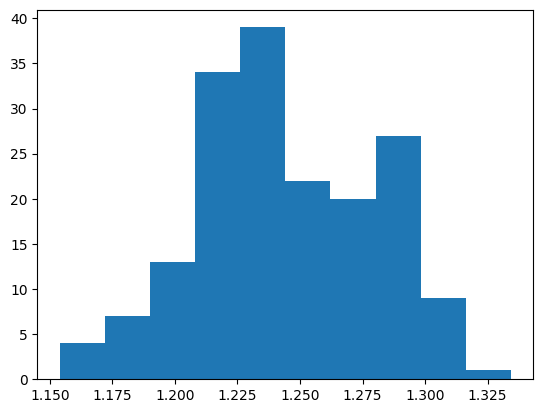

In [38]:
plt.hist(t[:, 0])

### ***Box-Cox transformation:*** **Only with *positive* features**

In [39]:
power = PowerTransformer("box-cox")

In [40]:
t = power.fit_transform(df)

In [41]:
t

array([[ 1.39346140e+00,  5.10442398e-01,  1.38067122e+00,
         1.39105660e+00,  8.85068620e-01],
       [-8.37677678e-01,  3.27402107e-01, -5.97567205e-01,
        -9.22386959e-01,  2.69997336e+00],
       [-2.43204640e-01,  6.26686048e-01, -8.26543097e-02,
        -2.44701478e-01,  1.91604582e+00],
       [ 5.86077013e-01,  1.03782483e+00,  5.86176881e-01,
         6.00930879e-01, -9.19684557e-01],
       [-5.30284224e-03,  7.83288155e-01,  1.90539791e-01,
        -1.49936135e-02,  1.10065301e+00],
       [ 1.41468216e+00,  6.92722412e-01,  1.38067122e+00,
         1.47064870e+00,  1.43154652e-01],
       [-2.16123050e-01, -7.97506302e-01, -1.72494126e-01,
        -2.43860583e-01,  7.52623508e-01],
       [-1.75824295e+00, -1.78508277e+00, -1.79506091e+00,
        -1.77798772e+00,  4.20671749e-01],
       [ 8.88735298e-01, -6.13446161e-01,  9.93065696e-01,
         8.94315246e-01,  1.42720318e+00],
       [ 2.47934090e-01,  5.67896061e-01,  3.47362411e-01,
         2.12519023e-01

(array([ 4.,  7., 12., 34., 40., 22., 20., 28.,  8.,  1.]),
 array([-2.55704079, -2.04914826, -1.54125573, -1.0333632 , -0.52547066,
        -0.01757813,  0.4903144 ,  0.99820693,  1.50609946,  2.013992  ,
         2.52188453]),
 <BarContainer object of 10 artists>)

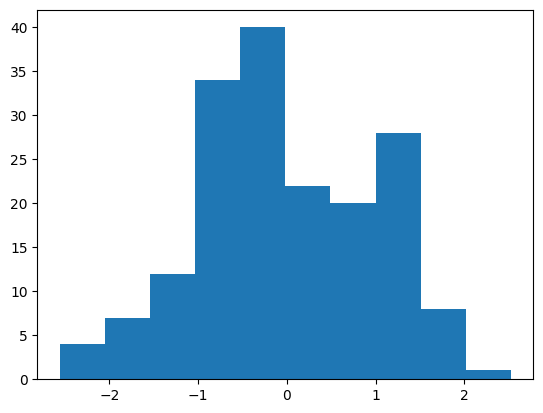

In [42]:
plt.hist(t[:, 0])